<a href="https://colab.research.google.com/github/suyon0416/26-2_ESAA_YB/blob/main/YB_0918(1)_exercises_chipotle_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [2]:
import pandas as pd

# 1. 주소 변수 지정
address = (
    "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"
)

# read_csv에서 구분자(sep)를 '\t'(탭)으로 지정하여 chipo 변수에 할당
chipo = pd.read_csv(address, sep="\t")

### Step 4. See the first 10 entries

In [3]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

item_name
Chicken Bowl           726
Chicken Burrito        553
Chips and Guacamole    479
Steak Burrito          368
Canned Soft Drink      301
Name: count, dtype: int64


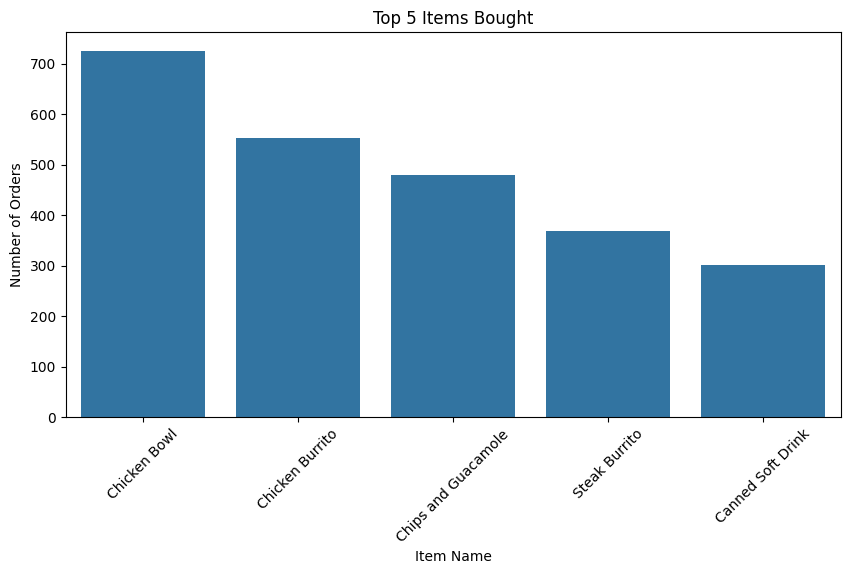

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 가장 많이 팔린 상위 5개 아이템 집계
top_5_items = chipo['item_name'].value_counts().head(5)

print(top_5_items)

# 2. 상위 5개 아이템 시각화
plt.figure(figsize=(10, 5))
sns.barplot(x=top_5_items.index, y=top_5_items.values)
plt.title('Top 5 Items Bought')
plt.xlabel('Item Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.show()

### Step 6. Create a scatterplot with the number of items ordered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

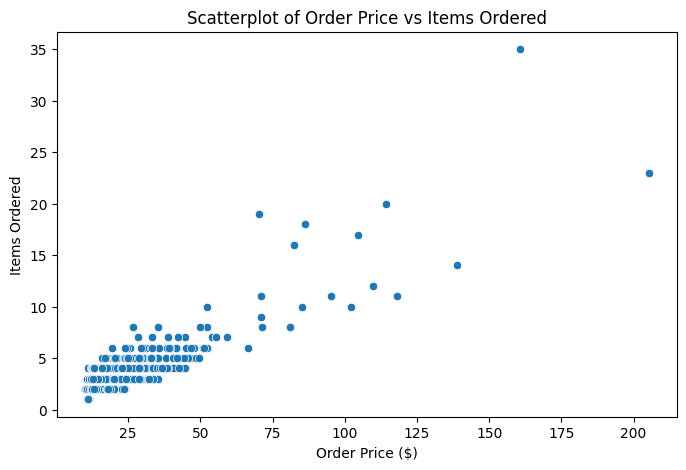

In [10]:
# 1. 가격($ 기호 제거 후 숫자로 변환)
chipo['item_price'] = chipo['item_price'].astype(str).str.replace('$', '', regex=False).astype(float)

# 2. 주문 번호(order_id)별로 총 가격과 수량 합치기
order_grouped = chipo.groupby('order_id').agg({'item_price': 'sum', 'quantity': 'sum'}).reset_index()

# 3. 산점도 그리기 (X축: 가격, Y축: 아이템 개수)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='item_price', y='quantity', data=order_grouped)

plt.title('Scatterplot of Order Price vs Items Ordered')
plt.xlabel('Order Price ($)')
plt.ylabel('Items Ordered')
plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

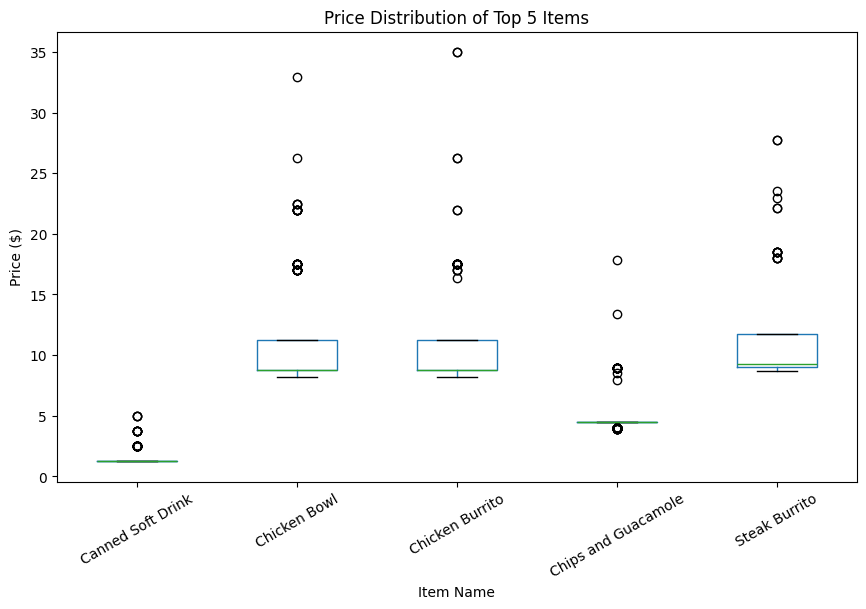

In [14]:
# 질문: 치폴레에서 가장 많이 판매되는 상위 5개 아이템의 가격 분포

# 상위 5개 아이템 데이터만 필터링
top_5_names = top_5_items.index
top_5_df = chipo[chipo['item_name'].isin(top_5_names)]

# 아이템별 가격 분포를 박스플롯(Boxplot)으로 시각화
top_5_df.boxplot(column='item_price', by='item_name', grid=False, figsize=(10, 6))
plt.title('Price Distribution of Top 5 Items')
plt.suptitle('')  # 자동 생성되는 판다스 타이틀 제거
plt.xlabel('Item Name')
plt.ylabel('Price ($)')
plt.xticks(rotation=30)
plt.show()